### Importing Pytorch libraries

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Downloading the train and test MNIST data, and passing it to the DataLoaders 

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
]) # to convert images into tensors, and also normalizing pixel values for stable learning, with mean=0.5, std=0.5

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # to create a data loader for mini-batch training, with batch size = 64, shuffled each epoch
test_loader  = DataLoader(test_dataset, batch_size=64)

### Defining the architecture of the model

In [ ]:
class FCNN(nn.Module): # inherit from nn.Module
    def __init__(self):
        super().__init__()
        # define the structure of each layer
        self.input = nn.Linear(28*28, 128) 
        self.h1 = nn.Linear(128, 128)
        self.h2 = nn.Linear(128, 128)
        self.out = nn.Linear(128, 10)
        
    # the forward pass into the model
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.input(x))
        x = torch.relu(self.h1(x))
        x = torch.relu(self.h2(x))
        x = self.out(x)
        return x
    
    # for predicting the digit
    def predict(self, x):
        with torch.no_grad(): # disable gradient tracking during inference
            logits = self(x) # get raw class scores (logits) 
            predictions = torch.argmax(logits, dim=1) # select the one with highest logit
            return predictions
        
model = FCNN() # initializing the model

### Defining the loss function and optimizer

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

### Training the model for 10 epochs

In [23]:
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    print(f"Epoch {epoch}, Loss={loss.item():.4f}")
    

Epoch 0, Loss=0.3809
Epoch 1, Loss=0.4175
Epoch 2, Loss=0.1116
Epoch 3, Loss=0.0720
Epoch 4, Loss=0.0083
Epoch 5, Loss=0.0198
Epoch 6, Loss=0.0312
Epoch 7, Loss=0.0113
Epoch 8, Loss=0.0952
Epoch 9, Loss=0.0061


In [24]:
import matplotlib.pyplot as plt
import numpy as np

### Visualising an image, and predicting its label

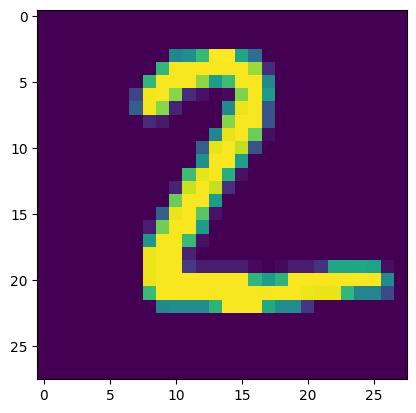

In [34]:
img, label = test_dataset[1]
plt.imshow(img.squeeze())


In [35]:
model.predict(img)

tensor([2])

### Computing the Train Accuracy

In [60]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total
print(f"Train Accuracy: {accuracy:}%")

Train Accuracy: 98.32333333333334%


### Computing the Train Accuracy

In [36]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:}%")

Test Accuracy: 96.95%


### Visualizing the weights of first hidden layer

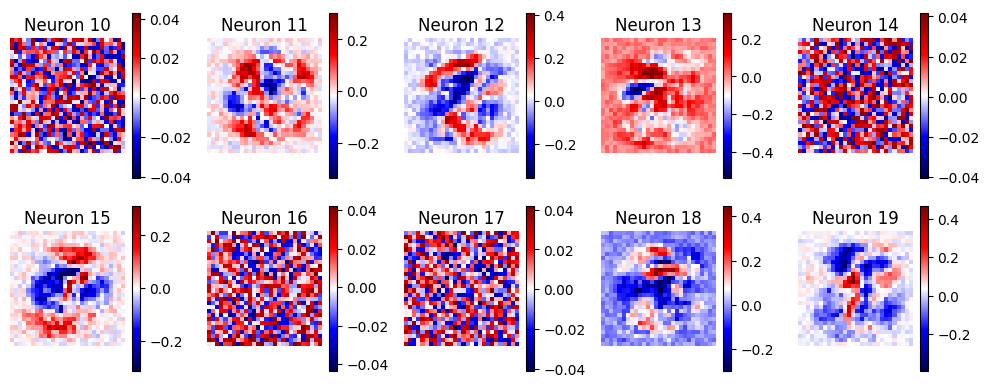

In [ ]:
weights = model.input.weight.data
plt.figure(figsize=(10, 4))
for i in range(10):
    w = weights[i].reshape(28, 28)
    plt.subplot(2, 5, i+1)
    plt.imshow(w, cmap="seismic")
    plt.colorbar()
    plt.title(f"Neuron {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()
